# 02 Data Cleaning

Objective: clean and aggregate the raw monthly trip files with a reproducible chunked workflow. The notebook regenerates `data/processed/` outputs and documents row removals.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "scripts").exists():
    ROOT_DIR = ROOT_DIR.parent

sys.path.append(str(ROOT_DIR / "scripts"))

pd.options.display.float_format = "{:,.2f}".format

from bikeshare_analysis import (
    build_quality_totals,
    configure_plot_style,
    plot_data_quality_removals,
    process_raw_data,
    read_processed,
)


## Run Cleaning Pipeline

The pipeline reads each ZIP in chunks, keeps raw files unchanged, removes only documented invalid records, and writes aggregate outputs to `data/processed/`.

In [2]:
key_metrics = process_raw_data()
quality_totals = build_quality_totals()
quality_lookup = quality_totals.set_index("metric")["value"].to_dict()

print(f"Rows read: {int(quality_lookup['rows_read']):,}")
print(f"Valid rows: {int(quality_lookup['valid_rows']):,}")
print(f"Rows removed: {int(quality_lookup['rows_removed']):,}")

Rows read: 5,601,662
Valid rows: 5,595,842
Rows removed: 5,820


## Data Quality Summary

In [3]:
quality = read_processed("data_quality_summary.csv")
display(quality)
display(quality_totals)

,month,source_file,rows_read,valid_rows,rows_removed,duplicate_ride_id,missing_datetime,invalid_member_type,out_of_scope_dates,nonpositive_duration,duration_over_24h,missing_start_station,missing_end_station
0,202503,202503-divvy-tripdata.zip,298155,297877,278,0,0,0,36,0,242,55332,57733
1,202504,202504-divvy-tripdata.zip,371341,371041,300,0,0,0,0,0,300,71196,73340
2,202505,202505-divvy-tripdata.zip,502456,501893,563,0,0,0,0,0,563,103360,106886
3,202506,202506-divvy-tripdata.zip,678904,677921,983,0,0,0,0,0,983,150904,155807
4,202507,202507-divvy-tripdata.zip,763432,762454,978,0,0,0,0,0,978,173529,180548
5,202508,202508-divvy-tripdata.zip,790177,789475,702,0,0,0,0,0,702,177121,184070
6,202509,202509-divvy-tripdata.zip,714759,714141,618,0,0,0,0,0,618,156261,163877
7,202510,202510-divvy-tripdata.zip,646039,645440,599,0,0,0,0,0,599,144979,152882
8,202511,202511-divvy-tripdata.zip,356628,356262,366,0,0,0,0,29,337,76276,81568
9,202512,202512-divvy-tripdata.zip,140534,140409,125,0,0,0,0,0,125,26926,29922


,metric,value
0,month,2430278
1,rows_read,5601662
2,valid_rows,5595842
3,rows_removed,5820
4,duplicate_ride_id,0
5,missing_datetime,0
6,invalid_member_type,0
7,out_of_scope_dates,36
8,nonpositive_duration,29
9,duration_over_24h,5755


## Rows Removed by Rule

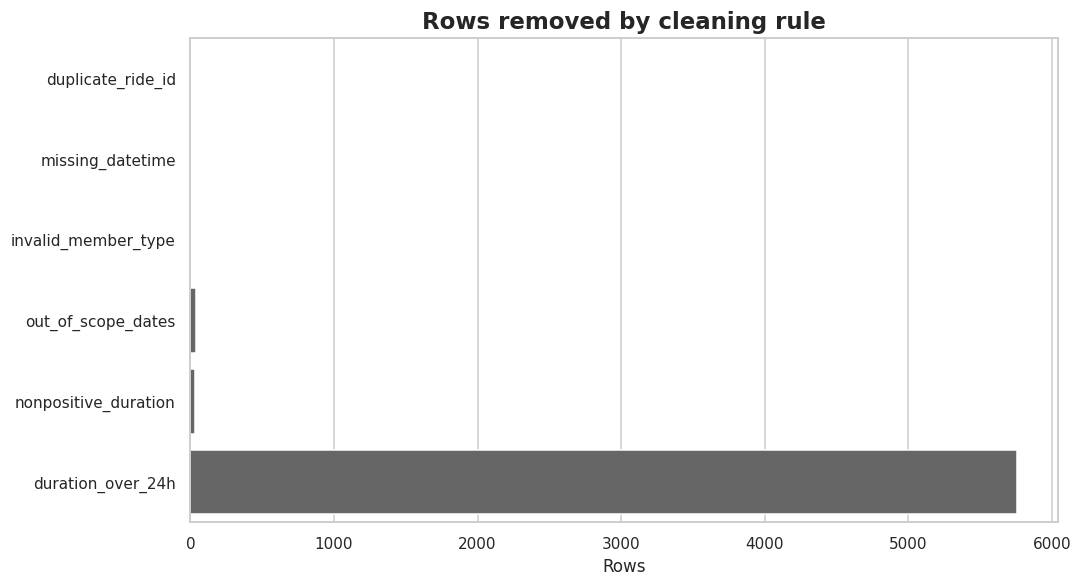

In [4]:
configure_plot_style()
fig = plot_data_quality_removals(quality_totals)
plt.show()

## Cleaned Output Check

In [5]:
overall = read_processed("overall_summary.csv")
display(overall)

display(pd.DataFrame({
    "created_columns": key_metrics["created_columns"],
}))

,member_casual,rides,ride_minutes,avg_ride_minutes,total_ride_hours,max_ride_minutes,most_common_day_of_week
0,casual,2008741,"38,429,863.53",19.13,"640,497.73","1,439.98",Saturday
1,member,3587101,"43,093,850.16",12.01,"718,230.84","1,439.90",Thursday


,created_columns
0,ride_length_min
1,month
2,day_of_week_num
3,day_of_week
4,start_hour
5,is_weekend
6,is_commute_window
7,is_round_trip


Cleaning note: rows with missing station names remain valid for time-based analysis. Station ranking tables exclude blank start station names so the location comparison is interpretable.